# report_labels（单篇研报未来验证 Label）产物分析

本 notebook **只读分析** `artifacts/report_labels/` 下的产物：

| 文件 | 内容 | 规模 |
| --- | --- | --- |
| `label_metadata.json` | 构建配置 / 输入源 / 计数 | 1 个 JSON |
| `label_coverage_audit.csv` | 覆盖率与失效原因长表 | 机器可读 |
| `reports.parquet` | 2024 全年单篇研报（文本 + 元信息） | 93,731 篇 |
| `report_fy_labels.parquet` | 研报 × 预测财年（FY0/1/2）行 | 258,161 行 |
| `report_confirmation_labels.parquet` | 未来确认 Label（月份 × 面板 × 前瞻期） | 1,548,966 行 |

这些产物由 `label_engineering/build_report_labels.py` 生成，核心计算在 `src/report_labeling.py`：

- `report_id = SHA256(stock|org|author|publish_ts|title)`，同一篇报告可覆盖多个预测财年 `fy`；
- `forecast_horizon = fy - year(available_date)`，只保留 0/1/2 三个前瞻期；
- `scale_t = max(|consensus_pre|, point_in_time_floor)`，所有 scale 化指标统一除以它；
- 三大 Label：**Residual**（报告 vs Actual）、**Edge**（报告 vs 同行共识）、**Future Confirmation**（未来同行共识是否朝报告方向收敛）。

> **最重要的契约提醒（读产物前必看）：**
> 1. **Actual 未提供**（`metadata.sources.actuals = "unavailable"`），因此 Residual / Edge 标签全为空、
>    `residual_valid = edge_valid = 0`（`label_coverage_audit.csv` 中这两类 valid 计数为 0）。
> 2. **Future Confirmation 是唯一有实际值的预测标签**：
>    `progress_raw = (consensus_future - consensus_pre) / (forecast_new - consensus_pre)`，
>    表示未来同行共识朝报告自身预测收敛的程度（>0 朝报告方向，≈1 完全收敛，<0 背道而驰）。
> 3. `confirmation_valid` 是正式标签有效标志；`confirmation_probe_valid` 是可用于 probe 训练的更强子集
>    （要求 active 面板，或至少 2 家同行更新）。

In [1]:
# 环境与导入
%matplotlib inline
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq

ROOT = Path("/home/intern_fjq_2026/Projects/chinese-wwm-roberta")
if not (ROOT / "configs").is_dir():
    raise FileNotFoundError("请在本项目服务器上运行，或修改 ROOT")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ART = ROOT / "artifacts" / "report_labels"
assert ART.is_dir(), f"产物目录不存在: {ART}"

plt.rcParams["font.sans-serif"] = ["WenQuanYi Micro Hei", "WenQuanYi Zen Hei",
                                   "AR PL UMing CN", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("python:", sys.version.split()[0], "| pandas:", pd.__version__,
      "| numpy:", np.__version__, "| pyarrow:", pa.__version__)
print("ART:", ART)

python: 3.10.18 | pandas: 1.5.3 | numpy: 1.24.4 | pyarrow: 19.0.1
ART: /home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/report_labels


In [2]:
# 1) 构建元信息 label_metadata.json
meta = json.loads((ART / "label_metadata.json").read_text(encoding="utf-8"))

print("label_version:", meta["label_version"], "| created_at:", meta["created_at"])
print()
print("== configuration(关键项) ==")
cfg = meta["configuration"]
for k in ["coverage_start", "label_start", "label_end",
          "forecast_horizons", "confirmation_months", "lookback_days",
          "scale_history_months", "min_scale_samples", "forecast_np_unit_multiplier"]:
    if k in cfg:
        print(f"  {k}: {cfg[k]}")
print()
print("== sources ==")
for k, v in meta["sources"].items():
    if isinstance(v, dict):
        print(f"  {k}: {v.get('path')}  ({v.get('size_bytes', 0)/1e9:.2f} GB)")
    else:
        print(f"  {k}: {v}")
print()
print("== counts ==")
for k, v in meta["counts"].items():
    print(f"  {k}: {v}")

label_version: report_future_v1.0 | created_at: 2026-08-20T11:30:04

== configuration(关键项) ==
  coverage_start: 2010-01-01
  label_start: 2024-01-01
  label_end: 2024-12-31
  forecast_horizons: [0, 1, 2]
  confirmation_months: [1, 3]
  lookback_days: 180
  scale_history_months: 12
  min_scale_samples: 500
  forecast_np_unit_multiplier: 10000.0

== sources ==
  reports: /home/intern_fjq_2026/data/NLP/research_report/forecast_stk_20100101_20250831.jsonl  (10.40 GB)
  trading_calendar: /home/intern_fjq_2026/data/RTN_daily/trade_days.csv  (0.00 GB)
  actuals: unavailable
  actual_schema: unavailable

== counts ==
  input_lines: 3612132
  bad_json: 0
  outside_read_window: 2850671
  canonical_report_fy_rows_read: 715152
  reports_output: 93731
  report_fy_rows_output: 258161
  confirmation_rows_output: 1548966
  residual_valid: 0
  edge_valid: 0
  confirmation_valid: 814213
  confirmation_probe_valid: 692359


In [3]:
# 2) 覆盖率审计 label_coverage_audit.csv
audit = pd.read_csv(ART / "label_coverage_audit.csv")
print("audit 长表:", audit.shape, "| 字段:", list(audit.columns))
print()

# (1) Residual / Edge 全为空 —— Actual 未提供的直接证据
sel = audit[audit["label"].isin(["residual", "edge"])]
print("Residual/Edge valid 总计数:", int(sel[sel["status"] == "valid"]["count"].sum()))
print("Residual/Edge invalid 原因:", sel[sel["status"] == "invalid"]["reason"].unique().tolist())
print()

# (2) Future Confirmation 的 valid / probe_valid 计数(月 × 面板)
c = audit[audit["label"] == "confirmation"].copy()
cv = (c[c["status"].isin(["valid", "probe_valid"])]
      .pivot_table(index=["confirmation_months", "peer_panel"],
                   columns="status", values="count", aggfunc="sum"))
print("confirmation valid / probe_valid 计数(按月 × 面板, 跨前瞻期汇总):")
print(cv.astype(int).to_string())

audit 长表: (135, 10) | 字段: ['report_year', 'forecast_horizon', 'confirmation_months', 'peer_panel', 'label', 'status', 'reason', 'count', 'total_count', 'rate']

Residual/Edge valid 总计数: 0
Residual/Edge invalid 原因: ['actual_source_unavailable']

confirmation valid / probe_valid 计数(按月 × 面板, 跨前瞻期汇总):
status                          probe_valid   valid
confirmation_months peer_panel                     
1.0                 active            94443   94443
                    fixed            104518  149512
                    market           104344  148099
3.0                 active           126220  126220
                    fixed            131877  149512
                    market           130957  146427


In [4]:
# 3) 读取三张 parquet 与 schema 概览
rep = pd.read_parquet(ART / "reports.parquet")
fy = pd.read_parquet(ART / "report_fy_labels.parquet")
cf = pd.read_parquet(ART / "report_confirmation_labels.parquet")

for name, df in [("reports", rep), ("report_fy_labels", fy),
                 ("report_confirmation_labels", cf)]:
    print(f"{name:28s} shape={str(df.shape):20s} 内存~{df.memory_usage(deep=True).sum()/1e6:6.1f} MB")

print()
for f in ["reports.parquet", "report_fy_labels.parquet", "report_confirmation_labels.parquet"]:
    p = pq.ParquetFile(str(ART / f))
    cols = ", ".join(f"{fld.name}:{fld.type}" for fld in p.schema_arrow)
    print(f"[{f}] rows={p.metadata.num_rows}")
    print("    ", cols)
    print()

reports                      shape=(93731, 11)          内存~ 470.0 MB
report_fy_labels             shape=(258161, 47)         内存~ 336.6 MB
report_confirmation_labels   shape=(1548966, 31)        内存~ 932.7 MB

[reports.parquet] rows=93731
     report_id:string, source_report_ids:string, stock_code:string, org_id:string, author_name:string, title:string, content:string, text:string, publish_timestamp:timestamp[ns], publish_date:timestamp[ns], available_date:timestamp[ns]

[report_fy_labels.parquet] rows=258161
     report_id:string, source_report_ids:string, stock_code:string, org_id:string, author_name:string, title:string, publish_timestamp:timestamp[ns], publish_date:timestamp[ns], available_date:timestamp[ns], fy:int64, forecast_horizon:int64, forecast_new:double, forecast_values:string, forecast_conflict:int64, n_source_rows:int64, consensus_pre:double, mad_pre_abs:double, n_org_pre:int64, history_window_complete:int64, pre_invalid_reason:string, scale_reference:string, scale_sample_

## 一、`reports.parquet` —— 报告文本与元信息

In [5]:
# 报告表体检: 行数 / 唯一值 / 文本长度 / 发布-可用日
print("唯一值: report_id =", rep["report_id"].nunique(),
      "| stock_code =", rep["stock_code"].nunique(),
      "| org_id =", rep["org_id"].nunique())
print("report_id 唯一(无重复):", bool(rep["report_id"].is_unique))
print("available_date 覆盖: %s -> %s" %
      (rep["available_date"].min().date(), rep["available_date"].max().date()))
print()

tl = rep["text"].str.len()
print("text 字符长度分布:")
print(tl.describe([0.25, 0.5, 0.75, 0.9, 0.99]).round(1).to_string())
print()

shift = (rep["available_date"] - rep["publish_date"]).dt.days
print("available_date - publish_date(天数, 非交易日盘后归下一交易日) 分布:")
print(shift.value_counts().sort_index().head(10).to_string())
print()
print("机构研报量 top 10:")
print(rep["org_id"].value_counts().head(10).to_string())

唯一值: report_id = 93731 | stock_code = 3317 | org_id = 91
report_id 唯一(无重复): True
available_date 覆盖: 2024-01-02 -> 2024-12-31

text 字符长度分布:
count    93731.0
mean      1072.8
std        652.7
min          4.0
25%        869.0
50%       1118.0
75%       1340.0
90%       1741.0
99%       2917.0
max      12929.0

available_date - publish_date(天数, 非交易日盘后归下一交易日) 分布:
0    72143
1    13430
2     6768
3      472
4      382
5      422
6       14
7       32
8        5
9        4

机构研报量 top 10:
中金        4008
浙商证券      3588
华泰证券      3526
申万宏源证券    3520
国泰君安      3386
东吴证券      3161
国信证券      3042
长江证券      2886
中信建投      2854
中信证券      2778


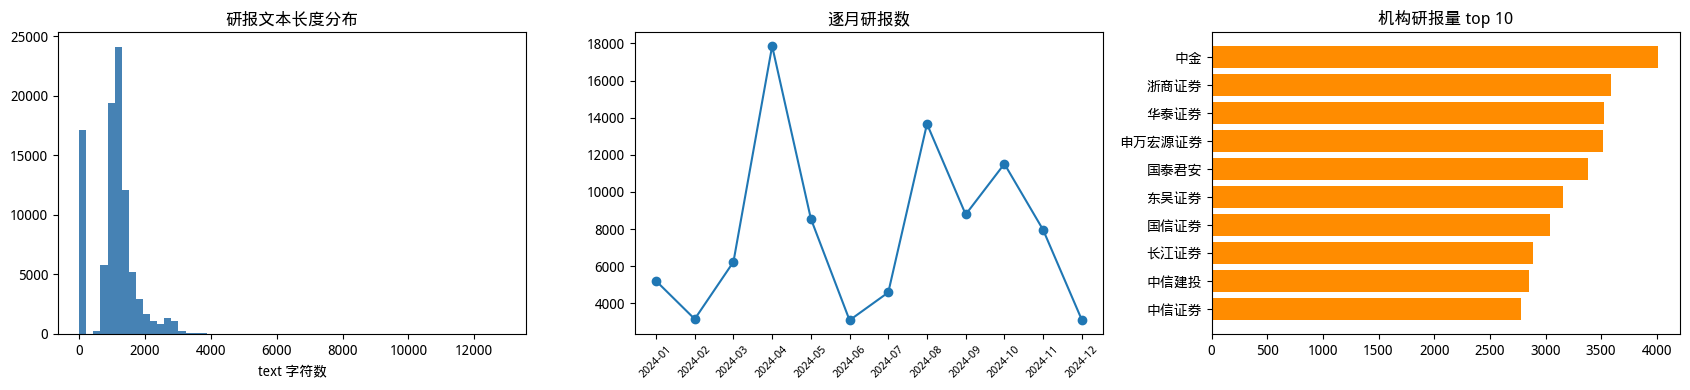

In [6]:
# 可视化: 文本长度 / 逐月研报数 / 机构 top10
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

axes[0].hist(rep["text"].str.len(), bins=60, color="steelblue")
axes[0].set_title("研报文本长度分布")
axes[0].set_xlabel("text 字符数")

monthly = rep.groupby(rep["available_date"].dt.to_period("M")).size()
axes[1].plot(monthly.index.astype(str), monthly.values, marker="o")
axes[1].set_title("逐月研报数")
axes[1].tick_params(axis="x", rotation=45, labelsize=8)

top10 = rep["org_id"].value_counts().head(10)
axes[2].barh(top10.index[::-1], top10.values[::-1], color="darkorange")
axes[2].set_title("机构研报量 top 10")

plt.tight_layout()
plt.show()

## 二、`report_fy_labels.parquet` —— 研报 × 预测财年行

In [7]:
# 前瞻期 / 发布前共识状态 / 有效位 概览
print("report_fy_labels:", fy.shape, "| 唯一 report_id:", fy["report_id"].nunique())
print("每篇报告覆盖的 FY 数分布(平均~2.75, 最多 3 个前瞻期):")
print(fy.groupby("report_id").size().describe().round(2).to_string())
print()
print("forecast_horizon 分布(0=当年, 1=次年, 2=后年):")
print(fy["forecast_horizon"].value_counts().sort_index().to_string())
print()
print("pre_state(发布前同行共识的盈利状态) 分布:")
print(fy["pre_state"].value_counts(dropna=False).to_string())
print()
print("pre_label_valid 分布:", fy["pre_label_valid"].value_counts().to_dict())
print("forecast_conflict(同报告多预测值冲突) 行数:", int(fy["forecast_conflict"].sum()))
print()
print("scale_reference 分布:", fy["scale_reference"].value_counts(dropna=False).to_dict())

report_fy_labels: (258161, 47) | 唯一 report_id: 93731
每篇报告覆盖的 FY 数分布(平均~2.75, 最多 3 个前瞻期):
count    93731.00
mean         2.75
std          0.48
min          1.00
25%          3.00
50%          3.00
75%          3.00
max          3.00

forecast_horizon 分布(0=当年, 1=次年, 2=后年):
0    93722
1    91556
2    72883

pre_state(发布前同行共识的盈利状态) 分布:
profit       245758
None          10155
loss           1977
near_zero       271

pre_label_valid 分布: {1: 225079, 0: 33082}
forecast_conflict(同报告多预测值冲突) 行数: 20

scale_reference 分布: {'same_horizon': 258161}


consensus_pre(发布前同行共识中位数, 原始元) 分布:
count    2.480060e+05
mean     6.433030e+09
std      2.356118e+10
min     -1.213200e+10
1%       2.500525e+07
50%      1.162940e+09
99%      1.168447e+11
max      4.047890e+11

dispersion_pre(MAD*1.4826 / scale_t) 分布:
count    248006.0000
mean          0.1011
std           1.0279
min           0.0000
1%            0.0000
50%           0.0578
99%           0.6155
max         427.8212

n_org_pre(发布前可用同行机构数) 分布:
count    258161.0
mean         16.7
std          11.5
min           0.0
25%           7.0
50%          15.0
75%          24.0
max          60.0



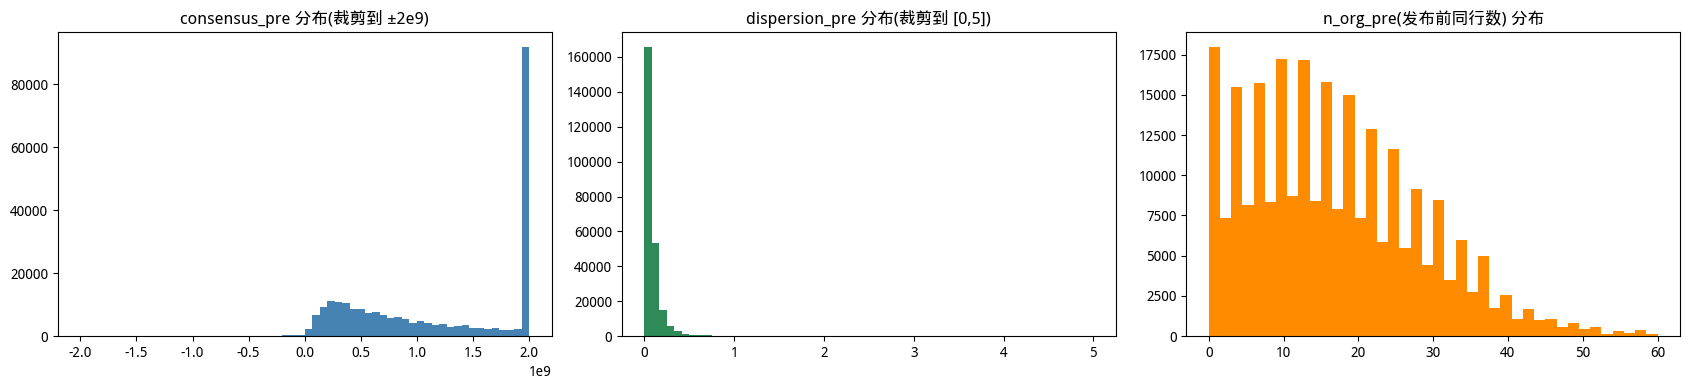

In [8]:
# 发布前共识 / 离散度 / 同行数 分布
print("consensus_pre(发布前同行共识中位数, 原始元) 分布:")
print(fy["consensus_pre"].describe([0.01, 0.5, 0.99]).round(0).to_string())
print()
print("dispersion_pre(MAD*1.4826 / scale_t) 分布:")
print(fy["dispersion_pre"].describe([0.01, 0.5, 0.99]).round(4).to_string())
print()
print("n_org_pre(发布前可用同行机构数) 分布:")
print(fy["n_org_pre"].describe().round(1).to_string())
print()

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
axes[0].hist(fy["consensus_pre"].clip(-2e9, 2e9).dropna(), bins=60, color="steelblue")
axes[0].set_title("consensus_pre 分布(裁剪到 ±2e9)")
axes[1].hist(fy["dispersion_pre"].clip(0, 5).dropna(), bins=60, color="seagreen")
axes[1].set_title("dispersion_pre 分布(裁剪到 [0,5])")
axes[2].hist(fy["n_org_pre"].dropna(), bins=40, color="darkorange")
axes[2].set_title("n_org_pre(发布前同行数) 分布")
plt.tight_layout()
plt.show()

In [9]:
# 关键契约确认: Actual 未提供 -> Residual/Edge 全为空
print("actual_np 缺失:", int(fy["actual_np"].isna().sum()), "/", len(fy))
print("residual_valid == 1:", int(fy["residual_valid"].sum()))
print("edge_valid       == 1:", int(fy["edge_valid"].sum()))
print("actual_invalid_reason 唯一值:", fy["actual_invalid_reason"].unique().tolist())

actual_np 缺失: 258161 / 258161
residual_valid == 1: 0
edge_valid       == 1: 0
actual_invalid_reason 唯一值: ['actual_source_unavailable']


## 三、`report_confirmation_labels.parquet` —— 未来确认标签

In [10]:
# 形状校验与有效覆盖率
print("report_confirmation_labels:", cf.shape)
expected = len(fy) * 2 * 3  # report_fy 行数 × 2 个月份 × 3 种面板
print("行数校验 258161×2×3 =", expected,
      "->", "一致" if len(cf) == expected else "不一致!")
print()
print("confirmation_valid      总数:", int(cf["confirmation_valid"].sum()))
print("confirmation_probe_valid 总数:", int(cf["confirmation_probe_valid"].sum()))
print()

rate = (cf.groupby(["confirmation_months", "peer_panel", "forecast_horizon"])
          .agg(rows=("report_id", "size"),
               valid=("confirmation_valid", "sum"),
               probe_valid=("confirmation_probe_valid", "sum"))
          .reset_index())
rate["valid_rate"] = (rate["valid"] / rate["rows"]).round(4)
rate["probe_rate"] = (rate["probe_valid"] / rate["rows"]).round(4)
print("== valid / probe 覆盖率(月 × 面板 × 前瞻期) ==")
print(rate[["confirmation_months", "peer_panel", "forecast_horizon",
            "rows", "valid_rate", "probe_rate"]].to_string(index=False))

report_confirmation_labels: (1548966, 31)
行数校验 258161×2×3 = 1548966 -> 一致

confirmation_valid      总数: 814213
confirmation_probe_valid 总数: 692359

== valid / probe 覆盖率(月 × 面板 × 前瞻期) ==
 confirmation_months peer_panel  forecast_horizon  rows  valid_rate  probe_rate
                   1     active                 0 93722      0.3932      0.3932
                   1     active                 1 91556      0.3952      0.3952
                   1     active                 2 72883      0.2936      0.2936
                   1      fixed                 0 93722      0.6033      0.4327
                   1      fixed                 1 91556      0.6038      0.4342
                   1      fixed                 2 72883      0.5170      0.3322
                   1     market                 0 93722      0.5969      0.4319
                   1     market                 1 91556      0.5973      0.4333
                   1     market                 2 72883      0.5141      0.3319
               

In [11]:
# 失效原因拆解
tot = len(cf)
print("invalid_reason 占全部行的比例(%):")
print((cf["invalid_reason"].value_counts(dropna=True) / tot * 100).round(2).to_string())
print()

cross = (cf.groupby(["peer_panel", "invalid_reason"]).size().unstack(fill_value=0))
share = cross.div(cf.groupby("peer_panel").size(), axis=0) * 100
print("各面板主要失效原因占比(%):")
print(share.round(2).to_string())

invalid_reason 占全部行的比例(%):
report_inline_with_consensus    25.30
insufficient_pre_peers          12.81
insufficient_active_peers        8.95
insufficient_future_peers        0.37
conflicting_report_forecast      0.01

各面板主要失效原因占比(%):
invalid_reason  conflicting_report_forecast  insufficient_active_peers  insufficient_future_peers  insufficient_pre_peers  report_inline_with_consensus
peer_panel                                                                                                                                             
active                                 0.01                      26.86                       0.00                   12.81                         17.58
fixed                                  0.01                       0.00                       0.00                   12.81                         29.27
market                                 0.01                       0.00                       1.11                   12.81                         29.03


In [12]:
# progress: 未来共识朝报告方向收敛的程度(只统计有效样本)
v = cf[cf["confirmation_valid"] == 1].copy()
print("progress_raw 分布:")
print(v["progress_raw"].describe([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4).to_string())
print()
print("progress_clipped(clip 到 [-1, 2]) 分布:")
print(v["progress_clipped"].describe([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4).to_string())
print()
pos = v.assign(_pos=(v["progress_raw"] > 0).astype(float))
print("progress_raw > 0(共识朝报告方向) 的比例(月 × 面板):")
print(pos.groupby(["confirmation_months", "peer_panel"])["_pos"].mean().round(4).to_string())

progress_raw 分布:
count    814213.0000
mean          0.3782
std           1.4548
min        -663.1257
1%           -2.6055
5%           -0.6386
25%           0.0000
50%           0.1888
75%           0.7426
95%           1.8129
99%           3.9560
max          43.9726

progress_clipped(clip 到 [-1, 2]) 分布:
count    814213.0000
mean          0.3684
std           0.6526
min          -1.0000
1%           -1.0000
5%           -0.6386
25%           0.0000
50%           0.1888
75%           0.7426
95%           1.8129
99%           2.0000
max           2.0000

progress_raw > 0(共识朝报告方向) 的比例(月 × 面板):
confirmation_months  peer_panel
1                    active        0.7546
                     fixed         0.5045
                     market        0.6600
3                    active        0.7295
                     fixed         0.6347
                     market        0.7341


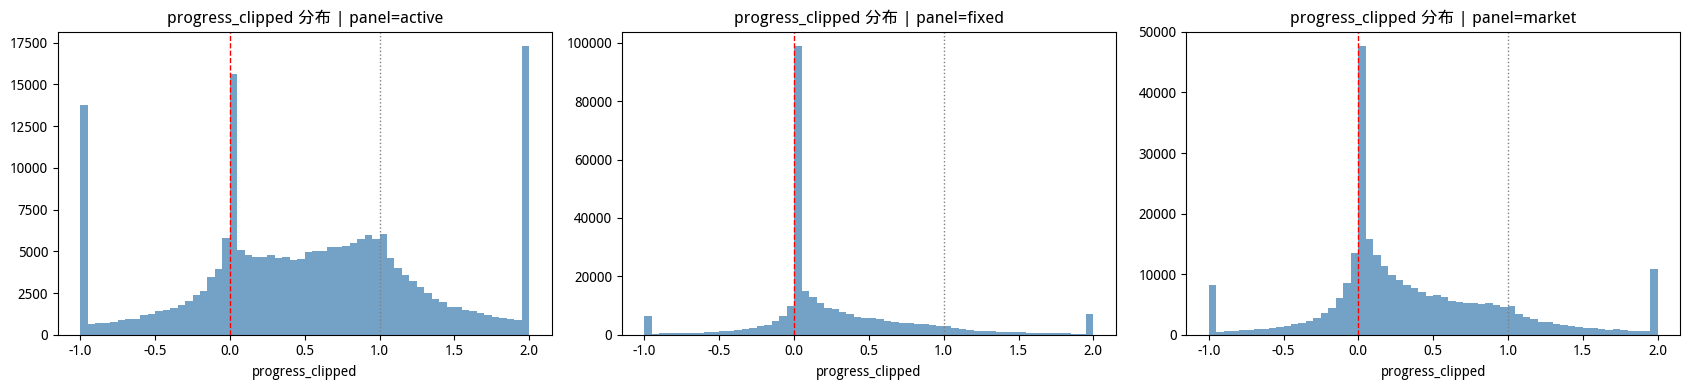

progress_clipped 均值(月 × 面板):
peer_panel           active   fixed  market
confirmation_months                        
1                    0.5246  0.1651  0.2402
3                    0.5593  0.3404  0.4690


In [13]:
# 可视化: 三种面板的 progress_clipped 分布 + 1/3 个月均值对比
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, panel in zip(axes, ["active", "fixed", "market"]):
    sub = v[v["peer_panel"] == panel]
    ax.hist(sub["progress_clipped"], bins=60, alpha=0.75, color="steelblue")
    ax.axvline(0, color="red", lw=1, ls="--")
    ax.axvline(1, color="gray", lw=1, ls=":")
    ax.set_title(f"progress_clipped 分布 | panel={panel}")
    ax.set_xlabel("progress_clipped")
plt.tight_layout()
plt.show()

piv = v.pivot_table(index="confirmation_months", columns="peer_panel",
                    values="progress_clipped", aggfunc="mean")
print("progress_clipped 均值(月 × 面板):")
print(piv.round(4).to_string())

delta_log_dispersion 分布(有效样本):
count    814213.0000
mean         -0.0320
std           0.8315
min         -14.8827
1%           -2.2031
5%           -1.2078
25%          -0.3244
50%           0.0000
75%           0.2724
95%           1.1103
99%           1.9953
max          16.4277

分歧收窄(delta<0) 的比例(月 × 面板):
confirmation_months  peer_panel
1                    active        0.5648
                     fixed         0.3100
                     market        0.4583
3                    active        0.5803
                     fixed         0.3887
                     market        0.5549



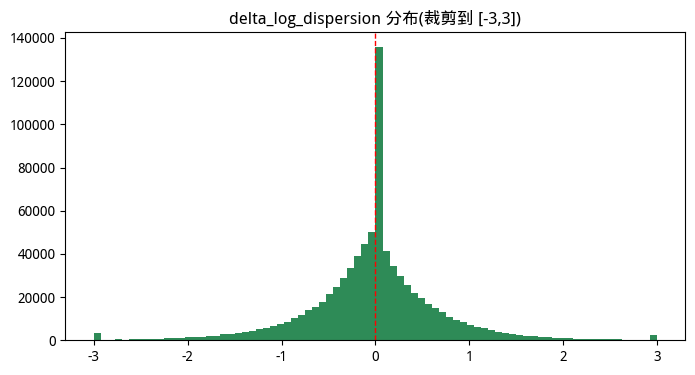

In [14]:
# 共识分歧变化: delta_log_dispersion = log(dispersion_future / dispersion_pre)
print("delta_log_dispersion 分布(有效样本):")
print(v["delta_log_dispersion"].describe([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(4).to_string())
print()
shrink = v.assign(narrower=v["delta_log_dispersion"] < 0)
print("分歧收窄(delta<0) 的比例(月 × 面板):")
print(shrink.groupby(["confirmation_months", "peer_panel"])["narrower"].mean().round(4).to_string())
print()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(v["delta_log_dispersion"].clip(-3, 3), bins=80, color="seagreen")
ax.axvline(0, color="red", lw=1, ls="--")
ax.set_title("delta_log_dispersion 分布(裁剪到 [-3,3])")
plt.show()

In [15]:
# 样本权重 sample_weight(probe_valid 子集)
pv = cf[cf["confirmation_probe_valid"] == 1]
print("sample_weight 分布(probe_valid 子集):")
print(pv["sample_weight"].describe([0.01, 0.25, 0.5, 0.75, 0.99]).round(4).to_string())
print()
print("sample_weight < 1 占比:", round(float((pv["sample_weight"] < 1).mean()), 4))
print("sample_weight = sqrt(coverage_weight × update_weight)，值越低代表同行覆盖/更新越弱")

sample_weight 分布(probe_valid 子集):
count    692359.0000
mean          0.9577
std           0.0717
min           0.7293
1%            0.7603
25%           0.9312
50%           1.0000
75%           1.0000
99%           1.0000
max           1.0000

sample_weight < 1 占比: 0.3414
sample_weight = sqrt(coverage_weight × update_weight)，值越低代表同行覆盖/更新越弱


In [16]:
# 交叉: progress_clipped × 发布前共识状态 / 前瞻期
ref = fy[["report_id", "fy", "pre_state"]].drop_duplicates(["report_id", "fy"])
v2 = v.merge(ref, on=["report_id", "fy"], how="left")

print("progress_clipped 均值 × pre_state(发布前共识状态):")
print(v2.groupby("pre_state")["progress_clipped"].agg(["mean", "median", "count"]).round(4).to_string())
print()
print("progress_clipped 均值 × 前瞻期 × 面板:")
print(v2.pivot_table(index="forecast_horizon", columns="peer_panel",
                     values="progress_clipped", aggfunc="mean").round(4).to_string())

progress_clipped 均值 × pre_state(发布前共识状态):
             mean  median   count
pre_state                        
loss       0.2214  0.0156    5157
near_zero  0.3049  0.0499     630
profit     0.3694  0.1902  808426

progress_clipped 均值 × 前瞻期 × 面板:
peer_panel        active   fixed  market
forecast_horizon                        
0                 0.6275  0.3016  0.4179
1                 0.5412  0.2617  0.3654
2                 0.4136  0.1664  0.2420


## 四、结论与建议

**产物结构**：2024 全年 93,731 篇研报 → 258,161 条「报告 × FY」预测行 → 1,548,966 条未来确认标签
（每条 × 2 个月份 × 3 种同行面板）。

**关键发现：**
- **Actual 缺失**是当前最大缺口：Residual / Edge 标签全为空（valid = 0），暂时只有 **Future Confirmation** 可用。
- **Future Confirmation 有效性**：正式有效 `confirmation_valid` 约 52.6%，probe 有效 `confirmation_probe_valid` 约 44.7%。
  `fixed` 面板有效样本最多（~57.9%），`active` 面板有效样本最少（~36.6% → ~48.9%）但“纯度”最高。
- **失效原因**（占全部行）：`report_inline_with_consensus` 约 25%（报告没有偏离共识、无信息量）、
  `insufficient_pre_peers` 约 13%、`insufficient_active_peers` 约 9%、`insufficient_future_peers` 约 0.4%。
- **progress 信号**：有效样本中 `progress_raw` 中位约 0.19、均值约 0.38，约 63%～75% 的样本未来共识朝报告方向移动；
  `active` 面板的 progress 均值/中位最高（更“前瞻”），`fixed` 面板最弱（近随机游走）。
  1 个月窗口的 progress 弱于 3 个月窗口（更长时间让共识有时间移动）。
- **分歧变化**：有效样本中 `delta_log_dispersion` 均值略为负（约 -0.03），说明被“确认”的报告后续同行分歧趋于收窄。

**训练建议：**
- 回归标签优先用 `progress_clipped`（已裁剪到 [-1, 2]），分类标签可用 `progress_raw` 的符号或 ±阈值；
- 训练 probe 时优先 `confirmation_probe_valid == 1`，并按 `sample_weight` 加权（弱覆盖/弱更新的样本降权）；
- 下一步若需 Residual / Edge 标签，请补齐 Actual 数据源与 `report_actual_schema.yaml`；
- 后续可将 `report_id` 对齐 `artifacts/research_report_probs_forecast_stk_*.csv` 的推理概率做交叉验证。